In [1]:
import xarray as xr

ds = xr.open_dataset('~/Documents/Research/EquatorMix/EQUATORMIX/fastCTD_prof.nc',engine='netcdf4')

In [2]:
ds

<xarray.Dataset> Size: 103MB
Dimensions:        (iPROF: 13949, iTXT: 30, iDEPTH: 130)
Dimensions without coordinates: iPROF, iTXT, iDEPTH
Data variables: (12/14)
    prof_date      (iPROF) float64 112kB ...
    prof_YYYYMMDD  (iPROF) float64 112kB ...
    prof_HHMMSS    (iPROF) float64 112kB ...
    prof_lon       (iPROF) float64 112kB ...
    prof_lat       (iPROF) float64 112kB ...
    prof_descr     (iTXT, iPROF) |S1 418kB ...
    ...             ...
    prof_Tstd      (iPROF, iDEPTH) float64 15MB ...
    prof_Tweight   (iPROF, iDEPTH) float64 15MB ...
    prof_S         (iPROF, iDEPTH) float64 15MB ...
    prof_Sstd      (iPROF, iDEPTH) float64 15MB ...
    prof_Sweight   (iPROF, iDEPTH) float64 15MB ...
    prof_zmean     (iPROF, iDEPTH) float64 15MB ...

In [22]:
import pandas as pd
# Combine date and time into a datetime array
dates = ds['prof_YYYYMMDD'].values.astype(int)
times = ds['prof_HHMMSS'].values.astype(int)

# Convert to zero-padded strings
date_strs = dates.astype(str)
time_strs = times.astype(str)
time_strs = [t.zfill(6) for t in time_strs]  # ensure time is like 'HHMMSS'
# Combine into full datetime strings and convert to pandas datetime
datetime_strs = [d + t for d, t in zip(date_strs, time_strs)]
datetimes = pd.to_datetime(datetime_strs, format='%Y%m%d%H%M%S')

# Assign as coordinate and optionally swap dimensions
ds = ds.assign_coords(time=('iPROF', datetimes))
# ds_adcp = ds_adcp.swap_dims({'iPROF': 'time'})
ds = ds.assign_coords(depth=('iDEPTH', ds['prof_depth'].values*-1))
# ds_adcp = ds_adcp.swap_dims({'iDEPTH': 'depth'})
ds = ds.assign_coords(lat=('iPROF', ds['prof_lat'].values))
ds = ds.assign_coords(lon=('iPROF', ds['prof_lon'].values))


In [24]:
ds.prof_T

<xarray.DataArray 'prof_T' (iPROF: 13949, iDEPTH: 130)> Size: 15MB
[1813370 values with dtype=float64]
Coordinates:
    time     (iPROF) datetime64[ns] 112kB 2012-10-07T01:22:24 ... 2012-11-04T...
    depth    (iDEPTH) float64 1kB -0.5 -1.5 -2.5 ... -5.125e+03 -5.375e+03
    lat      (iPROF) float64 112kB -9.382 -9.382 -9.382 ... -1.717 -2.915 -2.919
    lon      (iPROF) float64 112kB 214.7 214.7 214.7 214.7 ... 222.8 222.3 222.3
Dimensions without coordinates: iPROF, iDEPTH

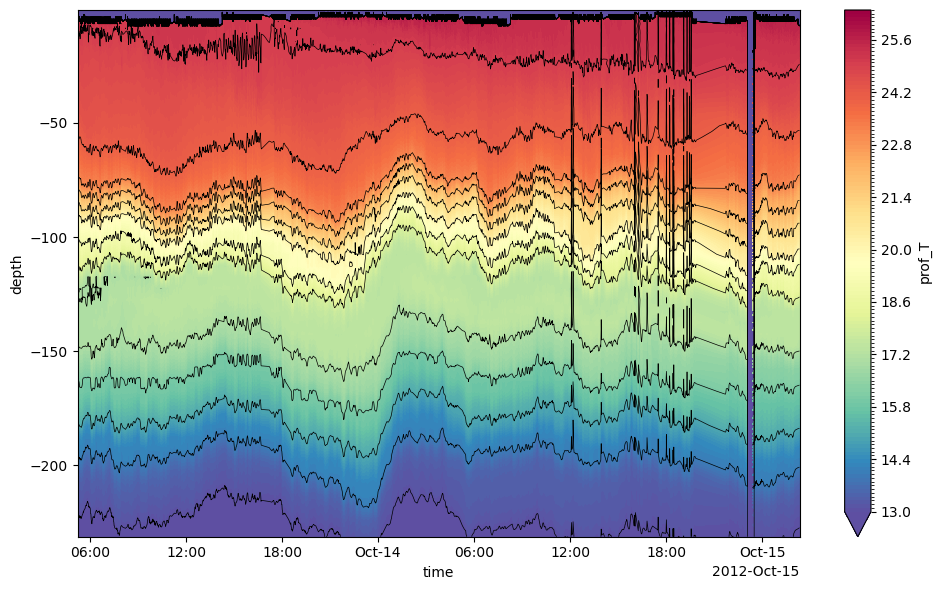

In [82]:
import numpy as np
import cmocean.cm as cmo
import matplotlib.pyplot as plt

levels = np.arange(13,26.5,0.1)
levels2 = np.arange(13,26.5,1)
fig, ax = plt.subplots(figsize=(10,6))
ds.prof_T.isel(iDEPTH=slice(0,70)).sel(iPROF=slice(2200,3800)).plot.contourf(ax=ax,levels=levels,x='time',y='depth',cmap='Spectral_r')
ds.prof_T.isel(iDEPTH=slice(0,70)).sel(iPROF=slice(2200,3800)).plot.contour(ax=ax,levels=levels2,x='time',y='depth',colors='k',linewidths=0.5)
plt.tight_layout()

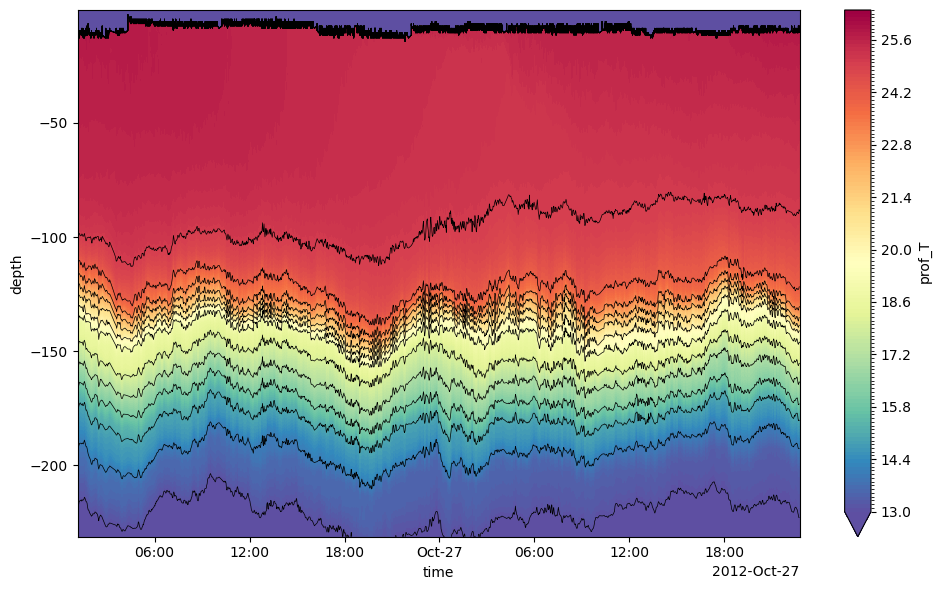

In [83]:

fig, ax = plt.subplots(figsize=(10,6))
ds.prof_T.isel(iDEPTH=slice(0,70)).sel(iPROF=slice(8000,9500)).plot.contourf(ax=ax,levels=levels,x='time',y='depth',cmap='Spectral_r')
ds.prof_T.isel(iDEPTH=slice(0,70)).sel(iPROF=slice(8000,9500)).plot.contour(ax=ax,levels=levels2,x='time',y='depth',colors='k',linewidths=0.5)
plt.tight_layout()

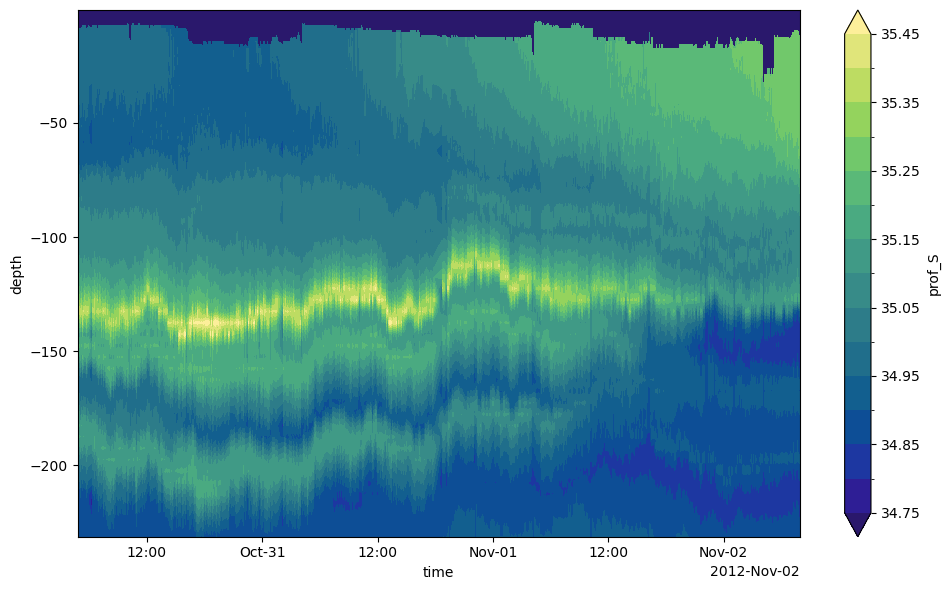

In [88]:
levels = np.arange(34.75,35.5,0.05)
levels2 = np.arange(34.75,35.5,.1)
fig, ax = plt.subplots(figsize=(10,6))
ds.prof_S.isel(iDEPTH=slice(0,70)).sel(iPROF=slice(11000,-500)).plot.contourf(ax=ax,levels=levels,x='time',y='depth',cmap=cmo.haline)
# ds.prof_S.isel(iDEPTH=slice(0,70)).sel(iPROF=slice(11000,-500)).plot.contour(ax=ax,levels=levels2,x='time',y='depth',colors='k',linewidths=0.5)
plt.tight_layout()

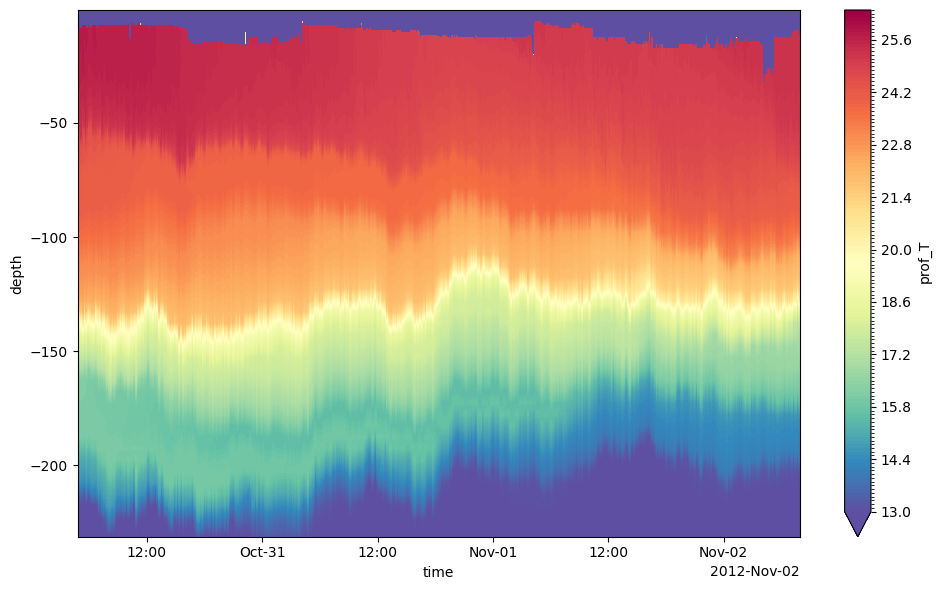

In [73]:
levels = np.arange(13,26.5,0.1)
levels2 = np.arange(13,26.5,1)
fig, ax = plt.subplots(figsize=(10,6))
ds.prof_T.isel(iDEPTH=slice(0,70)).sel(iPROF=slice(11000,-500)).plot.contourf(ax=ax,levels=levels,x='time',y='depth',cmap='Spectral_r')
# ds.prof_T.isel(iDEPTH=slice(0,70)).sel(iPROF=slice(11000,-500)).plot.contour(ax=ax,levels=levels2,x='time',y='depth',colors='k',linewidths=0.5)
plt.tight_layout()

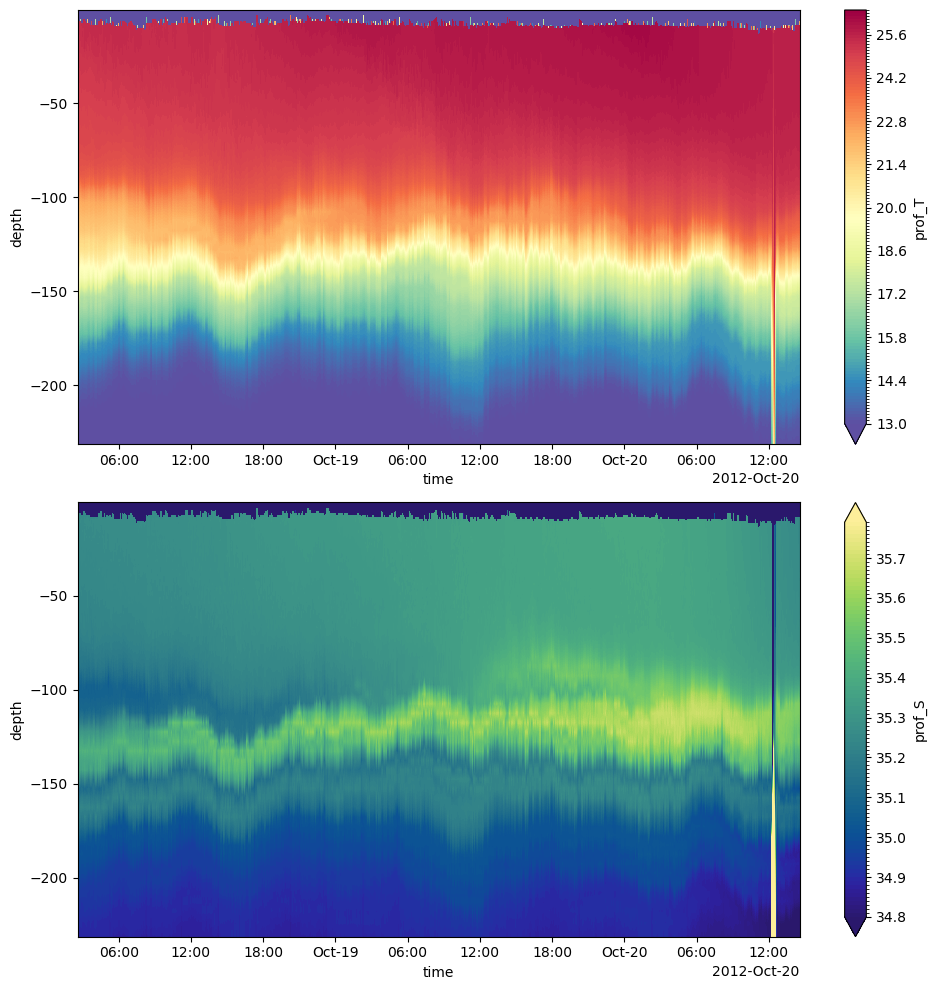

In [98]:

levels = np.arange(13,26.5,0.1)
levels2 = np.arange(13,26.5,1)
fig, ax = plt.subplots(figsize=(10,10),nrows=2)
ds.prof_T.isel(iDEPTH=slice(0,70)).sel(iPROF=slice(5200,7000)).plot.contourf(ax=ax[0],levels=levels,x='time',y='depth',cmap='Spectral_r')
levels = np.arange(34.8,35.8,0.01)
ds.prof_S.isel(iDEPTH=slice(0,70)).sel(iPROF=slice(5200,7000)).plot.contourf(ax=ax[1],levels=levels,x='time',y='depth',cmap=cmo.haline)
plt.tight_layout()

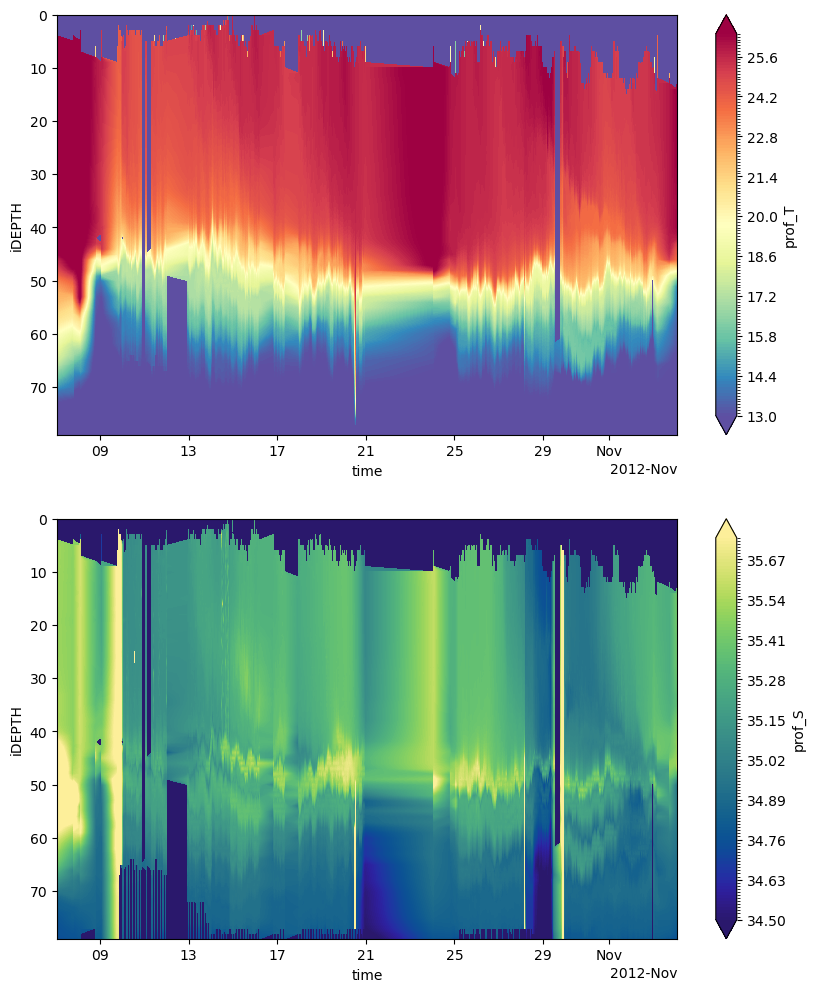

In [97]:
import numpy as np
import cmocean.cm as cmo

fig,ax=plt.subplots(figsize=(10,12),nrows=2)
levels= np.arange(13,26.5,0.1)
ds.prof_T.isel(iDEPTH=slice(0,80)).plot.contourf(ax=ax[0],x='time',levels=levels,cmap='Spectral_r',yincrease=False)
levels= np.arange(34.5,35.75,0.01)
ds.prof_S.isel(iDEPTH=slice(0,80)).plot.contourf(ax=ax[1],x='time',levels=levels,cmap=cmo.haline,yincrease=False)